# IRED Image Generation

Implements **Algorithm 2** from [Du et al., 2024](https://arxiv.org/pdf/2406.11179):

```
ŷ ~ N(0, 1)
for k = 0 → K-1:               # coarse→fine landscapes
    for t = 1 → T:             # gradient descent steps
        ŷ' ← ŷ - λ·∇_y E_θ(ŷ, k)
        if E(ŷ', k) < E(ŷ, k): accept ŷ'
    ŷ ← ŷ · √(1-σ_k²) / √(1-σ_{k-1}²)   # inter-landscape rescaling
return ŷ
```

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torchvision
import omegaconf
import random
from model import IREDEnergy
from ired import IREDTrainer

CHECKPOINT = "./checkpoints/energy_based_learning.pth"
DEVICE = "cuda"  # change to "cuda" or "cpu" if needed

## Load model

In [4]:
conf = omegaconf.OmegaConf.load("./config.yaml")

energy_model = IREDEnergy(conf)
trainer = IREDTrainer(energy_model, conf)

state = torch.load(CHECKPOINT, map_location=DEVICE)
trainer.load_state_dict(state)
trainer.to(DEVICE)
trainer.eval()

print(trainer)
print(f"\nSigma schedule (coarse→fine): {trainer.sigmas.tolist()}")

IREDTrainer(
  (model): IREDEnergy(
    (conv_trunk): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2), padding=(4, 4))
      (1): Swish()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): Swish()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): Swish()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): Swish()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=256, out_features=64, bias=True)
      (10): Swish()
    )
    (k_embedding): Embedding(10, 64)
    (energy_head): Sequential(
      (0): Swish()
      (1): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

Sigma schedule (coarse→fine): [0.949999988079071, 0.9216554760932922, 0.8400408625602722, 0.7150000333786011, 0.5616146326065063, 0.39838531613349915, 0.24500006437301636, 0.1199590414762497, 0.03834444284439087, 0.009999999776482582]


## Algorithm 2 — inference with per-landscape history

This extends the built-in `sample_annealed` to record:
- a snapshot of `ŷ` after each landscape
- the mean energy at each landscape after optimization

In [5]:
def sample_annealed_history(
    trainer: IREDTrainer,
    n_samples: int = 8,
    steps_per_landscape: int = None,   # defaults to trainer value
    step_size: float = None,           # defaults to trainer value
):
    """
    Algorithm 2 from IRED paper with per-landscape snapshots.

    @torch.no_grad() is intentionally NOT used here: torch.autograd.grad()
    needs gradient tracking enabled for the energy computation.
    torch.enable_grad() wraps only the gradient step; torch.no_grad() wraps
    the cheap accept/reject check so we don't build unnecessary graph nodes.

    Returns
    -------
    final       : (N, 1, 28, 28) — final generated images
    snapshots   : list of (N, 1, 28, 28) tensors, one per landscape
    energy_history : list of floats — mean energy after each landscape
    """
    T   = steps_per_landscape or trainer.inference_steps_per_landscape
    lr  = step_size            or trainer.inference_step_size
    K   = trainer.num_landscapes
    dev = trainer.device

    # Algorithm 2, line 1: ŷ ~ N(0, 1)
    y_hat = torch.randn(n_samples, 1, 28, 28, device=dev)

    snapshots      = []
    energy_history = []

    for k in range(K):
        sigma_k    = trainer.sigmas[k]
        sigma_prev = trainer.sigmas[k - 1] if k > 0 else trainer.sigmas[k]
        k_idx = torch.full((n_samples,), k, device=dev, dtype=torch.long)

        # --- T steps of gradient descent with accept/reject (Algorithm 2, lines 4-9) ---
        for _ in range(T):
            # enable_grad so autograd.grad can differentiate through the energy model
            with torch.enable_grad():
                y_hat  = y_hat.detach().requires_grad_(True)
                energy = trainer._energy(y_hat, k_idx)
                grad   = torch.autograd.grad(energy.sum(), y_hat, create_graph=False)[0]

            y_next = (y_hat.detach() - lr * grad.detach()).clamp(-1.0, 1.0)

            # accept step only where energy decreased
            with torch.no_grad():
                e_next = trainer._energy(y_next, k_idx)
                
                accept = (e_next < energy.detach()).view(-1, 1, 1, 1)
                y_hat  = torch.where(accept, y_next, y_hat.detach())

        # record mean energy after optimising this landscape
        with torch.no_grad():
            e_final = trainer._energy(y_hat, k_idx)
        energy_history.append(e_final.mean().cpu().item())

        # --- inter-landscape rescaling (Algorithm 2, line 12) ---
        with torch.no_grad():
            scale      = torch.sqrt(torch.clamp(1.0 - sigma_k    ** 2, min=1e-8))
            scale_prev = torch.sqrt(torch.clamp(1.0 - sigma_prev ** 2, min=1e-8))
            y_hat      = (y_hat * (scale / scale_prev.clamp(min=1e-8))).detach()

        snapshots.append(y_hat.clone().cpu())

    return y_hat.cpu(), snapshots, energy_history

## Run inference

In [6]:
N_SAMPLES          = 16
STEPS_PER_LANDSCAPE = 20   # increase for better quality (paper uses 40)
STEP_SIZE           = 0.05  # λ_k

final, snapshots, energy_history = sample_annealed_history(
    trainer,
    n_samples=N_SAMPLES,
    steps_per_landscape=STEPS_PER_LANDSCAPE,
    step_size=STEP_SIZE,
)

print(f"Generated {N_SAMPLES} images through {len(snapshots)} landscapes")
print(f"Energy per landscape: {[f'{e:.2f}' for e in energy_history]}")

Generated 16 images through 10 landscapes
Energy per landscape: ['112.34', '104.40', '63.86', '39.01', '44.19', '23.74', '13.63', '21.10', '105.03', '93.86']


## Energy across landscapes

Energy should decrease as we move from coarse (k=0) to fine (k=K-1) landscapes — the model converges toward the data manifold.

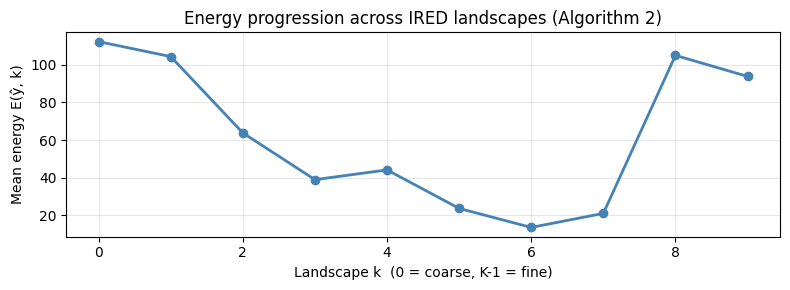

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(len(energy_history)), energy_history, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel("Landscape k  (0 = coarse, K-1 = fine)")
ax.set_ylabel("Mean energy E(ŷ, k)")
ax.set_title("Energy progression across IRED landscapes (Algorithm 2)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optimization trajectory — one sample across all landscapes

Shows how a single sample is refined from pure noise (k=0) to a sharp image (k=K-1).

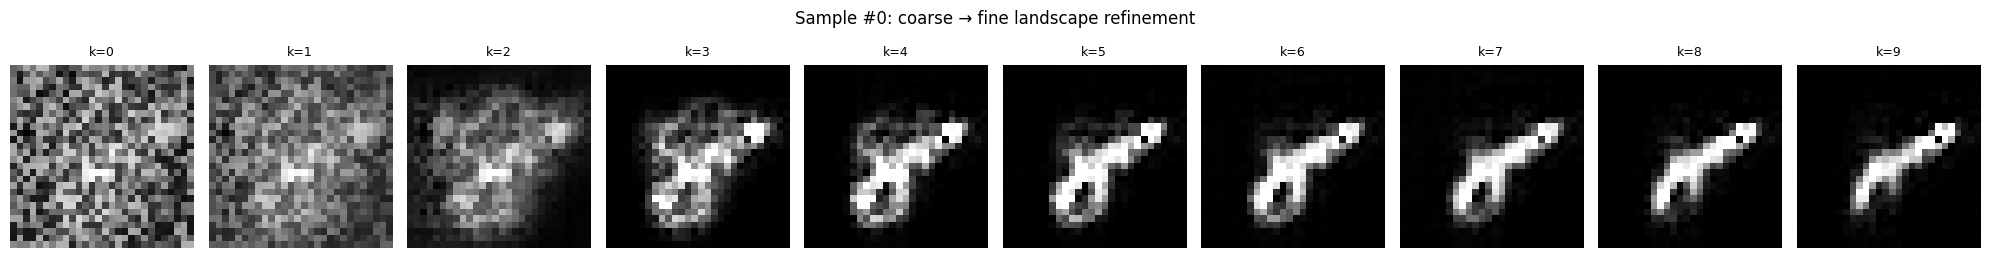

In [11]:
SAMPLE_IDX = 0  # which sample to visualize
K = len(snapshots)

# pick a subset of landscapes to show if K is large
show_at = list(range(0, K, max(1, K // 10))) + [K - 1]
show_at = sorted(set(show_at))

fig, axes = plt.subplots(1, len(show_at), figsize=(2 * len(show_at), 2.5))
if len(show_at) == 1:
    axes = [axes]

for ax, k in zip(axes, show_at):
    img = snapshots[k][SAMPLE_IDX].squeeze().numpy()
    # rescale from model range to [0,1] for display
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"k={k}", fontsize=9)
    ax.axis('off')

fig.suptitle(f"Sample #{SAMPLE_IDX}: coarse → fine landscape refinement", y=1.02)
plt.tight_layout()
plt.show()

## Final generated images

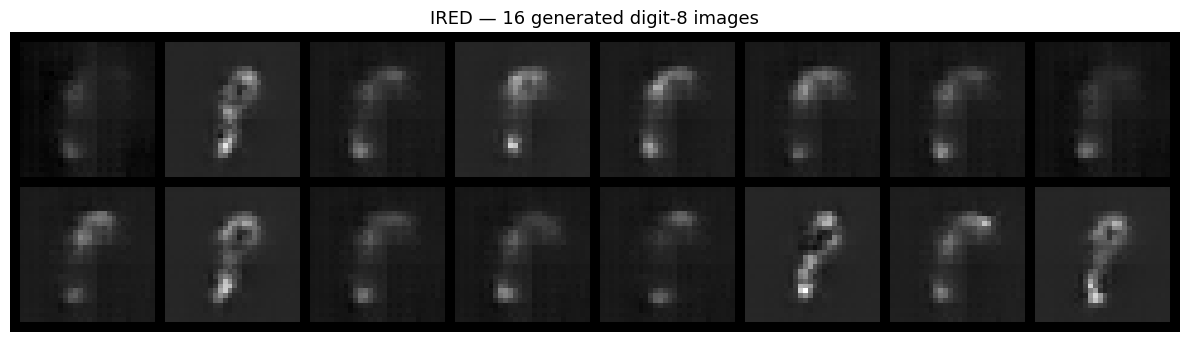

In [7]:
def show_grid(samples, nrow=8, title="Generated samples"):
    grid = torchvision.utils.make_grid(
        samples,
        nrow=nrow,
        normalize=True,  # rescales to [0, 1] across the whole grid
        padding=2,
    )
    np_grid = grid.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(figsize=(min(nrow * 1.5, 16), max(2, len(samples) // nrow * 1.5 + 1)))
    ax.imshow(np_grid, cmap='gray')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(final, nrow=8, title=f"IRED — {N_SAMPLES} generated digit-8 images")

## Effect of inference-time compute

The paper (Table 2) shows that more optimization steps at inference improve generalization. 
Here we compare the same random seed at different step counts.

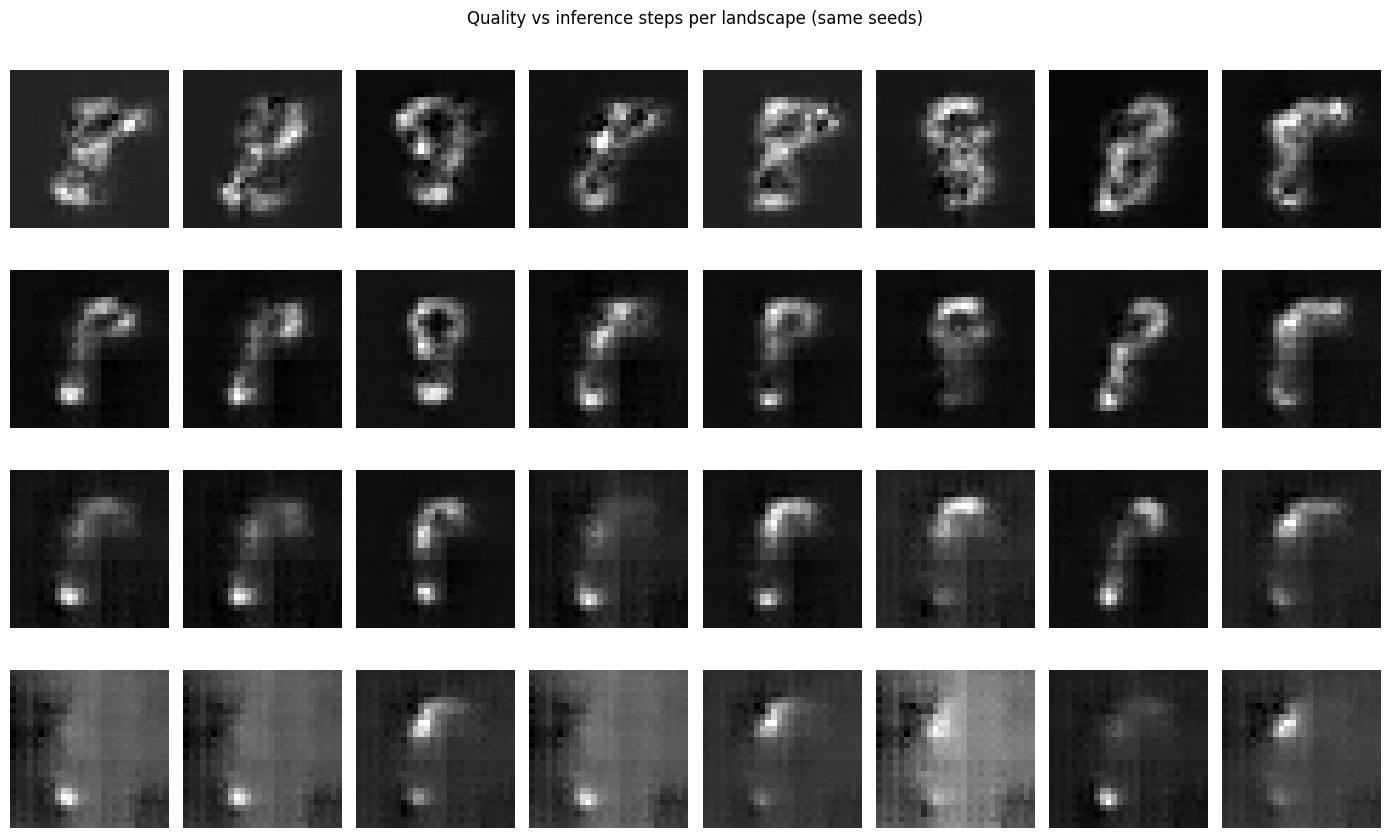

In [8]:
torch.manual_seed(42)
step_counts = [5, 10, 20, 40]

fig, axes = plt.subplots(len(step_counts), 8, figsize=(14, 2.2 * len(step_counts)))

for row, T in enumerate(step_counts):
    torch.manual_seed(42)  # same init noise every row
    imgs, _, _ = sample_annealed_history(trainer, n_samples=8, steps_per_landscape=T, step_size=STEP_SIZE)
    for col in range(8):
        img = imgs[col].squeeze().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f"T={T}", fontsize=10, rotation=0, labelpad=30, va='center')

fig.suptitle("Quality vs inference steps per landscape (same seeds)", fontsize=12)
plt.tight_layout()
plt.show()